In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_regression

# Indications :
### Donnéees :
- $X$ : la matrice des variables explicatives (features)
- $y$ : la variable cible (target)
### Autres
- $\theta$ : Le biais
- $n$ : le nombre de variables explicatives
- $m$ : le nombre d'exemple dans le datasets
- $\alpha$ : le pas de l'apprentissage
### Les formules mathématiques :
- Modèle : $F=X.\theta$
  
- Fonction Coût : $J(\theta) = \frac{1}{2m}\sum(X.\theta-y)^2$

  
- Gradients : $\frac{\partial J(\theta)}{\partial \theta} = \frac{1}{m}X^T.(X.\theta - y)$

- Descente de Gradient : $\theta := \theta - \alpha\frac{\partial J(\theta)}{\partial \theta}$

- Coefficent de determination $r = 1 - \frac{\sum(y - y\_pred)^2}{\sum(y - y\_mean)^2}$

# Programation

### Model

In [3]:
def model(X, theta):
    return X.dot(theta)

### Fonction coût 

In [4]:
def fonction_cout(X, y, theta):
    m = len(y) 
    return 1/(2*m) * np.sum((model(X,theta)-y)**2)

### Le gradients

In [5]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)

### La descente de gradient

In [6]:
def gradient_descent(X, y, theta, learning_rate, n_iter):
    cost_history = np.zeros(n_iter)
    for k in range(0, n_iter):
        theta = theta - learning_rate * grad(X, y, theta)
        cost_history[k] = fonction_cout(X, y, theta)
    return theta, cost_history                             

### Coefficent de determination

In [7]:
def coef_determination(y, pred):
    u = ((y - pred)**2).sum()
    v = ((y - y.mean())**2).sum()
    return 1 - u/v

# Application

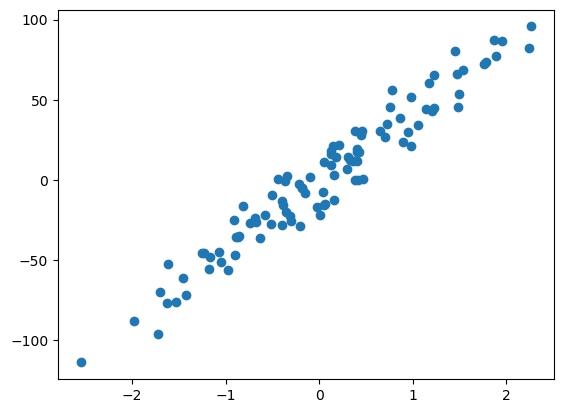

In [8]:
# Données
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=0)

plt.scatter(x[:, 0], y)

In [9]:
print(x.shape)
y = y.reshape(y.shape[0], 1)
print(y.shape)

(100, 1)
(100, 1)


In [10]:
# Matrice X
X = np.hstack((x, np.ones(x.shape)))
# Theta initial
theta = np.random.randn(x.shape[1]+1, 1)
print(theta)

[[-2.11559959]
 [ 1.18062749]]


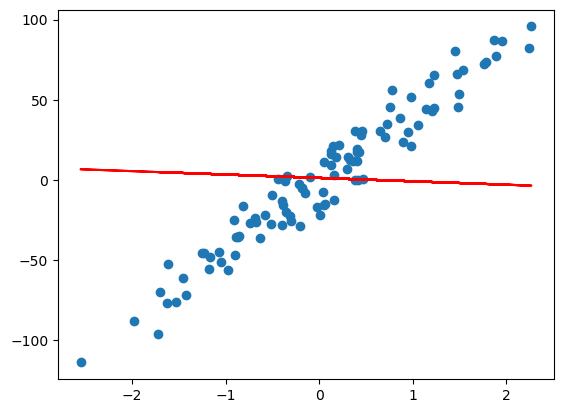

In [11]:
### Etat actuel du mondel

plt.scatter(x, y)
plt.plot(x[:,0], model(X, theta), c='r')

In [12]:
# Fonction Coût

fonction_cout(X, y, theta)

np.float64(1073.7651677139854)

In [13]:
theta_final, cost_history = gradient_descent(X, y, theta,learning_rate=0.01, n_iter=1000)

In [14]:
theta_final

array([[42.61747367],
       [-0.81295554]])

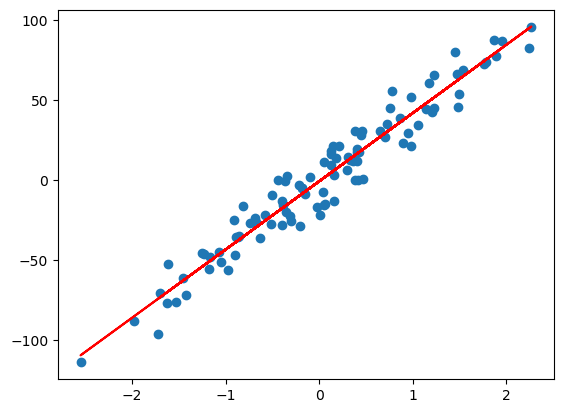

In [15]:
### Prédiction

y_pred = model(X, theta_final)

plt.scatter(x, y)
plt.plot(x,y_pred , c='r')

In [16]:
### L'erreur commise

fonction_cout(X, y, theta_final)

np.float64(57.08574564380558)

In [17]:
### Courbe d'apprentissage

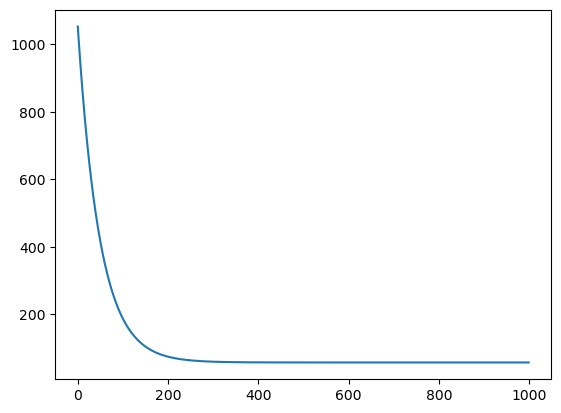

In [18]:
plt.plot(range(np.shape(cost_history)[0]), cost_history)

In [19]:
### Coefficent de determination

coef_determination(y, y_pred)

np.float64(0.9417294701582746)

# Bonus : 
### La Régression Lineaire sous forme de POO (model sklearn) avec deux algorithmes d'optimisation : descente de gradient et moindre carrée 

In [20]:
import numpy as np

class Linear_Regression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, method="gradient"):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.method = method.lower()
        self.theta = None
        self.mean = None
        self.std = None
        self.cost_history = None

    def _normalize(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        return (X - self.mean) / self.std  

    def _add_bias(self, X):
        return np.hstack((np.ones((X.shape[0], 1)), X))

    def _fonction_cout(self, y, predictions):
        m = len(y)
        return 1/(2*m) * np.sum((predictions-y)**2)

    def fit(self, X, y):
        X_norm = self._normalize(X)
        X_bias = self._add_bias(X_norm)
        m, n = X_bias.shape
        y = y.reshape(-1, 1)

        if self.method == "gradient":
            self.theta = np.zeros((n, 1))
            self.cost_history = np.zeros((self.n_iterations,1))
            for k in range(self.n_iterations):
                predictions = X_bias @ self.theta 
                error = predictions - y
                gradient = (1 / m) * (X_bias.T @ error)
                self.theta -= self.learning_rate * gradient
                self.cost_history[k] = self._fonction_cout(y, predictions)
        elif self.method == "normal":
            # Méthode des moindres carrées : (Xᵀ X)^(-1) Xᵀ y
            self.theta = np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y
        else:
            raise ValueError("Méthode inconnue. Utilisez 'gradient' ou 'normal'.")

    def predict(self, X):
        X_norm = (X - self.mean) / self.std
        X_bias = self._add_bias(X_norm)
        return X_bias @ self.theta

    def score(self, X, y):
        y = y.reshape(-1, 1)
        y_pred = self.predict(X)
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_res / ss_total)
        return r2

### Utilisation direct :

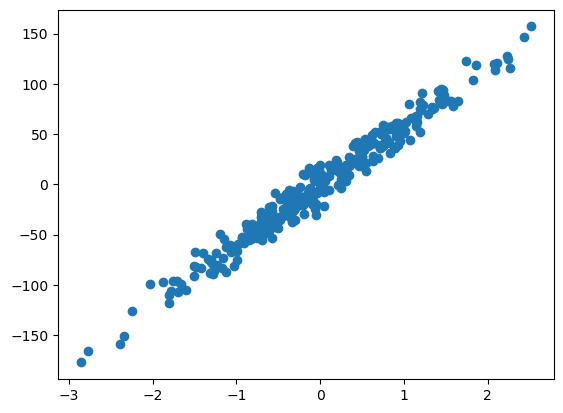

In [21]:
x, y = make_regression(n_samples=300, n_features=1, noise=10, random_state=5)

plt.scatter(x, y)

### Avec la descente de gradient

In [22]:
model1 = Linear_Regression(method='gradient')
model1.fit(x, y)
y_pred = model1.predict(x)
model1.score(x,y)

np.float64(0.9704239115399258)

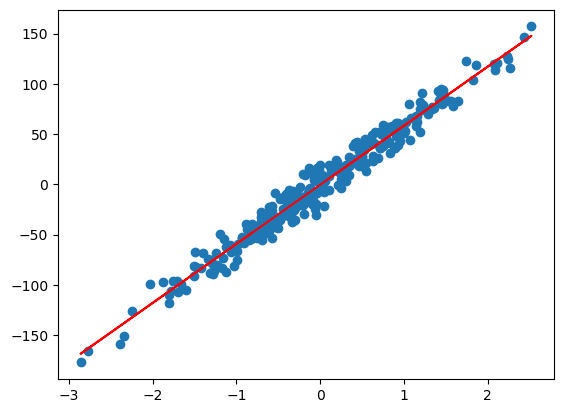

In [23]:
plt.scatter(x, y)
plt.plot(x, y_pred, c='r')

Text(0, 0.5, 'cout')

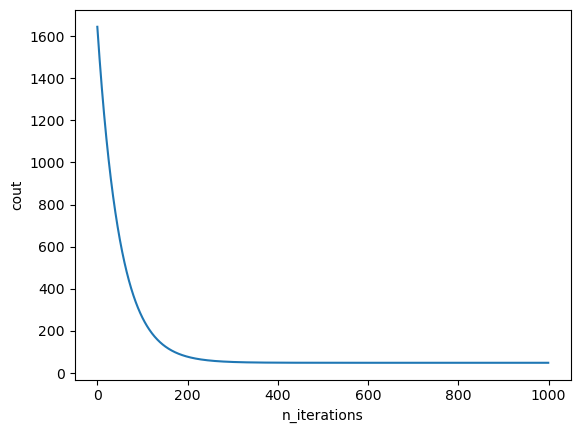

In [24]:
plt.plot(model1.cost_history)
plt.xlabel('n_iterations')
plt.ylabel('cout')

### Avec la methode des moindres carrées

In [25]:
model2 = Linear_Regression(method='normal')
model2.fit(x, y)
print(model2.score(x, y))
y_pred = model2.predict(x)

0.970423913348676


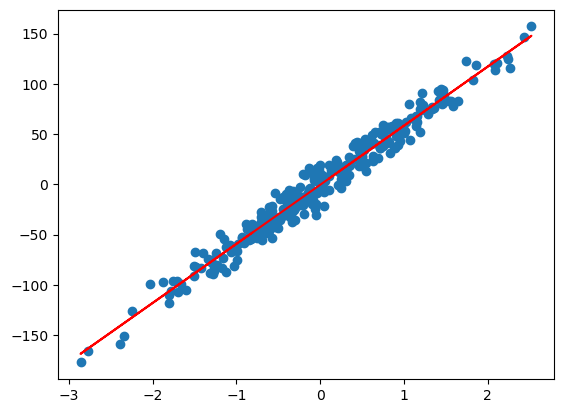

In [26]:
plt.scatter(x, y)
plt.plot(x, y_pred, c='r')